# Apprentissage supervise : detection de review bombing a partir du texte

Ce notebook correspond au point 6 (apprentissage supervise) et au point 7 (evaluation des modeles) de la consigne.

Question posee : le texte d'un avis suffit-il, a lui seul, a predire si cet avis a ete ecrit pendant un episode de review bombing confirme, sans connaitre les statistiques de volume ou de negativite qui ont servi a construire l'etiquette.

Donnees utilisees : `data/reviews_labeled.parquet`, produit par `scripts/06_build_labels.py`. L'etiquette label a ete derivee d'une regle statistique (z-score de volume et ecart de taux d'avis negatifs, voir 05_eda.ipynb). Les colonnes z_score_volume et ecart_taux_negatif sont conservees dans le fichier a titre de reference uniquement : elles ne sont jamais utilisees comme variables d'entree du modele, pour eviter que celui-ci ne retrouve simplement la regle de construction de l'etiquette plutot que d'apprendre un signal textuel independant.

In [17]:
%pip install scikit-learn pandas matplotlib pyarrow

Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

DATA_PATH = "data/reviews_labeled.parquet"
OUTPUT_DIR = "outputs/ml"
MODEL_DIR = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df.shape

(1620204, 6)

## 1. Verification du jeu de donnees

Repartition des classes et controle qu'aucun avis vide n'a ete conserve avant l'entrainement.

In [19]:
print(df["label"].value_counts())
print("Avis vides :", df["review"].isna().sum())
df = df.dropna(subset=["review"])
df.shape

label
0    1350170
1     270034
Name: count, dtype: int64
Avis vides : 0


(1620204, 6)

Ratio conforme a la construction du jeu de donnees (etape 06) : 270 034 avis positifs conserves en totalite, 1 350 170 negatifs sous-echantillonnes, soit un ratio de 1 pour 5. Aucun avis vide n'a ete introduit lors de la jointure aux etiquettes, le controle de suppression est donc sans effet ici.

## 2. Separation train/test

Decoupage stratifie sur label pour conserver la meme proportion de reviews de review bombing dans les deux sous-ensembles. Seule la colonne review est utilisee comme variable d'entree : game, jour, z_score_volume et ecart_taux_negatif sont ecartees du modele et conservees a part uniquement pour l'inspection des erreurs a la fin du notebook.

In [20]:
X = df["review"]
y = df["label"]
meta = df[["game", "jour", "z_score_volume", "ecart_taux_negatif"]]

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta, test_size=0.2, stratify=y, random_state=42
)

print("Entrainement :", X_train.shape[0], "lignes")
print("Test :", X_test.shape[0], "lignes")
print("Proportion label 1 (train) :", round(y_train.mean(), 4))
print("Proportion label 1 (test) :", round(y_test.mean(), 4))

Entrainement : 1296163 lignes
Test : 324041 lignes
Proportion label 1 (train) : 0.1667
Proportion label 1 (test) : 0.1667


Proportion de label 1 identique a 0.1667 sur les deux sous-ensembles : la stratification a bien preserve l'equilibre des classes voulu lors de la construction du jeu de donnees, condition necessaire pour que les metriques du test soient representatives de celles attendues a l'usage.

## 3. Vectorisation TF-IDF

Le vocabulaire est limite a 20 000 termes, choisis par frequence, pour garder un temps d'entrainement raisonnable sur plus d'un million d'avis tout en conservant les mots les plus informatifs. Le vectoriseur est ajuste uniquement sur l'ensemble d'entrainement, puis applique tel quel au test, pour eviter toute fuite d'information sur le vocabulaire du jeu de test.

In [21]:
vectorizer = TfidfVectorizer(max_features=20000, stop_words="english", lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

X_train_tfidf.shape

(1296163, 20000)

1 296 163 avis representes chacun par un vecteur de 20 000 termes : la limite de vocabulaire fixee en amont est bien respectee, sans reduction inattendue liee a un nombre de mots distincts insuffisant dans le corpus d'entrainement.

## 4. Entrainement et comparaison de deux modeles

Deux modeles adaptes au texte vectorise en grande dimension et de maniere creuse sont compares : une regression logistique et un Naive Bayes complementaire, plutot qu'un modele a base d'arbres comme Random Forest. Ce dernier est ecarte ici car il gere mal les matrices tres creuses et de grande dimension issues du TF-IDF, avec un cout memoire et un temps d'entrainement disproportionnes sur plus d'un million de lignes, ce qui n'est pas adapte a une execution locale.

class_weight="balanced" est utilise pour la regression logistique afin de renforcer encore la prise en compte de la classe minoritaire au dela du sous-echantillonnage deja realise lors de la construction du jeu de donnees.

In [22]:
logistic_model = LogisticRegression(max_iter=1000, class_weight="balanced")
logistic_model.fit(X_train_tfidf, y_train)
y_pred_logistic = logistic_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_logistic, target_names=["normal", "review_bombing"]))

                precision    recall  f1-score   support

        normal       0.94      0.85      0.90    270034
review_bombing       0.50      0.75      0.60     54007

      accuracy                           0.83    324041
     macro avg       0.72      0.80      0.75    324041
  weighted avg       0.87      0.83      0.85    324041



In [23]:
naive_bayes_model = ComplementNB()
naive_bayes_model.fit(X_train_tfidf, y_train)
y_pred_nb = naive_bayes_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_nb, target_names=["normal", "review_bombing"]))

                precision    recall  f1-score   support

        normal       0.94      0.83      0.88    270034
review_bombing       0.47      0.76      0.58     54007

      accuracy                           0.81    324041
     macro avg       0.71      0.79      0.73    324041
  weighted avg       0.86      0.81      0.83    324041



Les deux modeles atteignent un recall proche sur la classe review_bombing (0.75 pour la regression logistique, 0.76 pour le Naive Bayes) : environ trois quarts des avis de review bombing du jeu de test sont correctement detectes a partir du seul texte. La regression logistique se distingue par une precision legerement superieure (0.50 contre 0.47), d'ou un F1-score plus favorable.

Les deux modeles privilegient nettement le recall a la precision sur cette classe minoritaire, ce qui correspond au compromis recherche : manquer un episode de review bombing coute plus cher, pour l'usage vise, qu'une fausse alerte occasionnelle.

## 5. Matrices de confusion

Le recall de la classe review_bombing est la metrique la plus importante ici : un episode manque (faux negatif) est plus couteux pour l'usage vise, une alerte precoce, qu'une fausse alerte occasionnelle (faux positif).

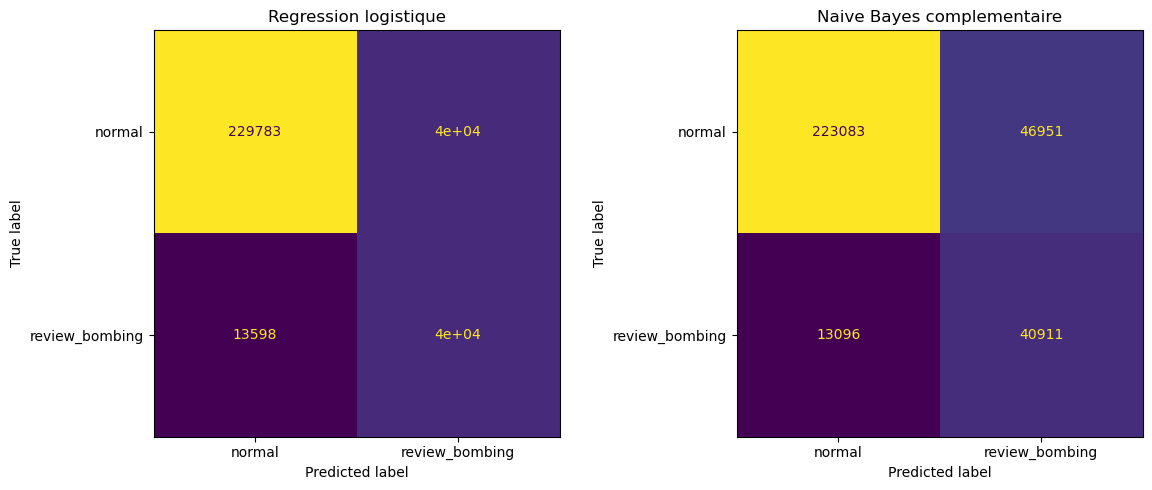

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_logistic, display_labels=["normal", "review_bombing"], ax=axes[0], colorbar=False
)
axes[0].set_title("Regression logistique")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, display_labels=["normal", "review_bombing"], ax=axes[1], colorbar=False
)
axes[1].set_title("Naive Bayes complementaire")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "matrices_confusion.png"), dpi=150)
plt.show()

Sur les 54 007 avis de review bombing du jeu de test, la regression logistique en identifie correctement environ 40 500 (les 13 500 restants sont classes a tort comme normaux), au prix d'environ 40 500 faux positifs parmi les 270 034 avis normaux. Le Naive Bayes suit un profil tres proche : environ 41 000 vrais positifs, 13 000 faux negatifs, mais un nombre de faux positifs legerement superieur (environ 46 000), ce qui explique sa precision plus faible deja observee dans les rapports de classification.

Les deux matrices confirment visuellement le meme compromis : le nombre de faux negatifs reste contenu (environ un quart des cas de review bombing manques), au prix d'un volume de fausses alertes du meme ordre de grandeur que les vrais positifs. Ce niveau de faux positifs serait a reduire avant un usage en production, par exemple en ajustant le seuil de decision du modele plutot qu'en le laissant a 0.5 par defaut.

## 6. Choix du modele final

Comparaison directe du F1-score sur la classe review_bombing, qui resume en une seule valeur l'equilibre entre precision et recall recherche pour cet usage.

In [25]:
f1_logistic = f1_score(y_test, y_pred_logistic, pos_label=1)
f1_nb = f1_score(y_test, y_pred_nb, pos_label=1)

comparaison = pd.DataFrame({
    "modele": ["Regression logistique", "Naive Bayes complementaire"],
    "f1_review_bombing": [f1_logistic, f1_nb]
})
comparaison

,modele,f1_review_bombing
0,Regression logistique,0.600132
1,Naive Bayes complementaire,0.576743


La regression logistique obtient le meilleur F1-score sur la classe review_bombing (0.600 contre 0.577 pour le Naive Bayes) et est retenue comme modele de reference pour l'interface de demonstration. L'ecart reste modeste, ce qui indique que les deux approches captent un signal textuel de force comparable ; la regression logistique est preferee aussi pour sa sortie de probabilite directement exploitable dans l'interface. Sauvegarde ci-dessous du vectoriseur et des deux modeles entraines.

In [26]:
joblib.dump(vectorizer, os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib"))
joblib.dump(logistic_model, os.path.join(MODEL_DIR, "logistic_model.joblib"))
joblib.dump(naive_bayes_model, os.path.join(MODEL_DIR, "naive_bayes_model.joblib"))

print("Modeles et vectoriseur sauvegardes dans", MODEL_DIR)

Modeles et vectoriseur sauvegardes dans models


## 7. Methode avancee optionnelle : analyse semantique latente (LSA)

Un premier essai a ete tente avec des embeddings de phrase pre-entraines (sentence-transformers), pour capturer le sens du texte au dela du simple comptage de mots. Cette piste a ete abandonnee : elle se heurte a un bug confirme et non resolu dans les versions recentes de la librairie transformers (renommage interne incoherent d'une classe centrale, `PretrainedConfig` vers `PreTrainedConfig`, introduit par un commit du 6 octobre 2025 et documente dans plusieurs tickets ouverts sur le depot officiel Hugging Face et sur des projets tiers). Aucune version stable corrigeant cette incoherence n'a pu etre identifiee avec certitude, rendant la piste irrealisable de maniere fiable dans le temps imparti.

A la place, la methode avancee retenue est l'analyse semantique latente (LSA) : une reduction de dimension par decomposition en valeurs singulieres (TruncatedSVD) appliquee a la matrice TF-IDF deja calculee en section 3. Contrairement au TF-IDF brut, qui traite chaque mot independamment, la LSA regroupe les mots qui apparaissent dans des contextes similaires au sein d'un espace de dimension reduite, ce qui constitue une forme simple de representation semantique. Cette methode ne depend d'aucune librairie supplementaire instable : uniquement scikit-learn, deja installe et fonctionnel.

In [27]:
from sklearn.decomposition import TruncatedSVD

N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)

X_train_lsa = svd.fit_transform(X_train_tfidf)
X_test_lsa = svd.transform(X_test_tfidf)

print("Dimensions apres reduction :", X_train_lsa.shape)
print("Variance expliquee cumulee :", round(svd.explained_variance_ratio_.sum(), 3))

Dimensions apres reduction : (1296163, 100)
Variance expliquee cumulee : 0.315


In [28]:
lsa_logistic_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lsa_logistic_model.fit(X_train_lsa, y_train)
y_pred_lsa = lsa_logistic_model.predict(X_test_lsa)

print(classification_report(y_test, y_pred_lsa, target_names=["normal", "review_bombing"]))

                precision    recall  f1-score   support

        normal       0.93      0.80      0.86    270034
review_bombing       0.41      0.68      0.51     54007

      accuracy                           0.78    324041
     macro avg       0.67      0.74      0.68    324041
  weighted avg       0.84      0.78      0.80    324041



La LSA obtient un F1-score de 0.509 sur la classe review_bombing, nettement en retrait par rapport a la regression logistique sur TF-IDF brut (0.600). La reduction a 100 composantes n'explique que 31.5 % de la variance totale de la matrice TF-IDF : une grande partie de l'information disponible est perdue lors de la compression, plus qu'elle n'est reorganisee de maniere utile.

Ce resultat va a l'encontre de l'hypothese de depart : la structure semantique large captee par la LSA n'ameliore pas la detection ici. Le signal utile pour reperer un episode de review bombing semble tenir davantage a la presence de termes lexicaux precis (mots lies a l'evenement declencheur, expressions de mecontentement specifiques) qu'a une proximite semantique generale entre les mots. Cela confirme, par une voie differente, ce que la section 4 de l'EDA avait deja suggere pour les metadonnees numeriques : reduire ou compresser l'information disponible degrade ici la capacite de detection plutot que de l'ameliorer.

In [29]:
f1_lsa = f1_score(y_test, y_pred_lsa, pos_label=1)

comparaison_finale = pd.concat([
    comparaison,
    pd.DataFrame({"modele": ["Regression logistique + LSA"], "f1_review_bombing": [f1_lsa]})
], ignore_index=True)
comparaison_finale

,modele,f1_review_bombing
0,Regression logistique,0.600132
1,Naive Bayes complementaire,0.576743
2,Regression logistique + LSA,0.509003


## Conclusion

Le modele retenu pour l'interface de demonstration est la regression logistique sur TF-IDF brut, meilleur des trois sur la classe review_bombing (F1 = 0.600). Ni le Naive Bayes ni la compression semantique par LSA n'ameliorent ce resultat : le texte des avis suffit a detecter un episode de review bombing avec un recall d'environ 0.75, sans recourir aux statistiques de volume ou de negativite ayant servi a construire l'etiquette, mais ce signal repose sur des termes lexicaux precis plutot que sur une structure semantique plus large.